# Self-consistent solution of the SYK equation using the Discrete Lehmann Representation

The goal of this tutorial is to showcase the use of the discrete Lehmann representation (DLR) to solve the Dyson equation self-consistently (i.e., given an expression for the self-energy in terms of the Green's function), by implementing a simple self-consistent loop for the Sachdev-Ye-Kitaev (SYK) model. For background on the DLR and its use in TRIQS, we refer to the [TRIQS documentation](https://triqs.github.io/triqs/latest/userguide/python/tutorials/Basics/solutions/01s-Greens_functions.html#Compact-meshes-for-imaginary-time-/-frequency:-DLR-Green%E2%80%99s-function). We note that although this is not a DMFT calculation, some of the main steps (Fourier transform between imaginary time and Matsubara frequency, solving the Dyson equation) are similar to those in a DMFT calculation.

### Constructing DLR Green's Functions

We begin by setting various parameters, building a DLR imaginary frequency mesh, and creating Green's function and self-energy containers from this mesh. The DLR parameters are the desired accuracy, `dlr_error`, and the problem bandwidth or frequency cutoff, `w_max`. We also set some physical problem parameters, as well as a maximum number of iterations for the self-consistency, a self-consistency convergence tolerance, and a mixing parameter $\alpha$.

In [100]:
from triqs.gf import *
from triqs.gf.tools import *
from triqs.operators import *
from triqs.gf.block_gf import *
from triqs.gf.descriptors import Function
import h5
import numpy as np
from triqs.plot.mpl_interface import *
import matplotlib.pyplot as plt
import matplotlib as mpl
import json, sys, os

params = {
    "beta": 1000.0,
    "mu": 0.0,
    "alpha" : 0.75,
    "w_max": 5.0,
    "dlr_err": 1e-8, 
    "J" : 1.0,
    "max_iter": 1000,
    "threshold": 1e-8,
}

gf_struct =[('up',1), ('dn',1)]
iw_mesh = MeshDLRImFreq(beta=params["beta"], statistic='Fermion', w_max= params["w_max"], eps = params["dlr_err"], symmetrize = True)
G_iw   = BlockGf(mesh=iw_mesh, gf_struct=gf_struct)
G_tau = make_gf_dlr_imtime(G_iw)
Sigma_iw = G_iw.copy()
Sigma_tau = make_gf_dlr_imtime(Sigma_iw)

### Exercise 1 
We first solve the $O+1$-dimensional (impurity) Sachdev-Ye-Kitaev (SYK) model self-consistently. The Hamiltonian is given by 
$$H = \sum^N_{ijkl} J_{ijkl} c^\dagger_i c^\dagger_j c_k c_l$$
where the $J_{ijkl}$ are random Gaussian couplings between $N$ fermions with constant variance $J^2$.
 This model has many interesting applications for non-Fermi liquids, or strange metals, and quantum criticality. You can read more about the model and its extensions [(here)](https://journals.aps.org/rmp/abstract/10.1103/RevModPhys.94.035004). Here we are interested in a simple form of the self-energy in the large-$N$ limit of the model, given by
\begin{equation}
\Sigma(\tau) = -J^2 G^2(\tau)G(-\tau).
\end{equation}
Combining this self-energy with the Dyson equation yields a self-consistent set of equations. These were solved using the DLR with weighted fixed point iteration in Sec. VII of [(this paper)](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.105.235115). Following that reference, it is your turn to write a self-consistent loop to solve for $G$.

As shown in the paper, as we approach the $\beta = \infty$ limit, the result should begin to match the conformal solution of these equations. Try comparing to the conformal solution! We should already have quite good agreement at $\beta = 1000$.
\begin{equation}
G_c(\tau)=-\frac{\pi^{1 / 4}}{\sqrt{2 \beta}}\left(\sin \left(\frac{\pi \tau}{\beta}\right)\right)^{-1 / 2}
\end{equation}

In [101]:
G_iw << SemiCircular(1.0)           # Initial guess for the Green's function  
G_tau << make_gf_dlr_imtime(G_iw)   # Initial guess in the imaginary time domain
error = 1.0
iter = 0

while error > params["threshold"]:
    for block, g in G_tau:
        Sigma_tau[block].data[:,0,0] = params["J"]**2 * g.data[:,0,0]**2*np.flip(g.data[:,0,0]) # Compute self-energy in imaginary time

    Sigma_iw << make_gf_dlr_imfreq(Sigma_tau)                                       # Transform self-energy to Matsubara frequency domain 

    for block, g in G_tau:
        G_iw[block] << inverse(iOmega_n - Sigma_iw[block])                          # Solve the Dyson equation to obtain Green's function
    G_old = G_tau.copy()
    G_tau << params["alpha"]*G_old + (1-params["alpha"])*make_gf_dlr_imtime(G_iw)   # Update Green's function via weighted fixed point iteration
    error = np.max(np.abs((G_tau["up"].data[:,0,0] - G_old["up"].data[:,0,0])))     # Compute absolute error
    iter += 1

    # Print iteration number and error
    print("Iteration:", iter, "Error:", error)
    if iter > params["max_iter"]:
        print("Maximum number of iterations reached without convergence")
        break

Iteration: 1 Error: 0.09365042856331773
Iteration: 2 Error: 0.023890918571245603
Iteration: 3 Error: 0.01772142056085254
Iteration: 4 Error: 0.012252912807243714
Iteration: 5 Error: 0.006978087034360904
Iteration: 6 Error: 0.0030978880192437525
Iteration: 7 Error: 0.001187108305732671
Iteration: 8 Error: 0.000452914315013514
Iteration: 9 Error: 0.0002086765906473831
Iteration: 10 Error: 0.00012219373055782912
Iteration: 11 Error: 7.295182635136399e-05
Iteration: 12 Error: 4.4238366217141945e-05
Iteration: 13 Error: 2.7150527487362908e-05
Iteration: 14 Error: 1.6816989099333046e-05
Iteration: 15 Error: 1.0655920738511515e-05
Iteration: 16 Error: 6.883502771670713e-06
Iteration: 17 Error: 4.471739080247339e-06
Iteration: 18 Error: 2.919701448056422e-06
Iteration: 19 Error: 1.9151486679303e-06
Iteration: 20 Error: 1.2615741412647097e-06
Iteration: 21 Error: 8.343275522681992e-07
Iteration: 22 Error: 5.538040315222759e-07
Iteration: 23 Error: 3.6886194482166346e-07
Iteration: 24 Error: 2.4

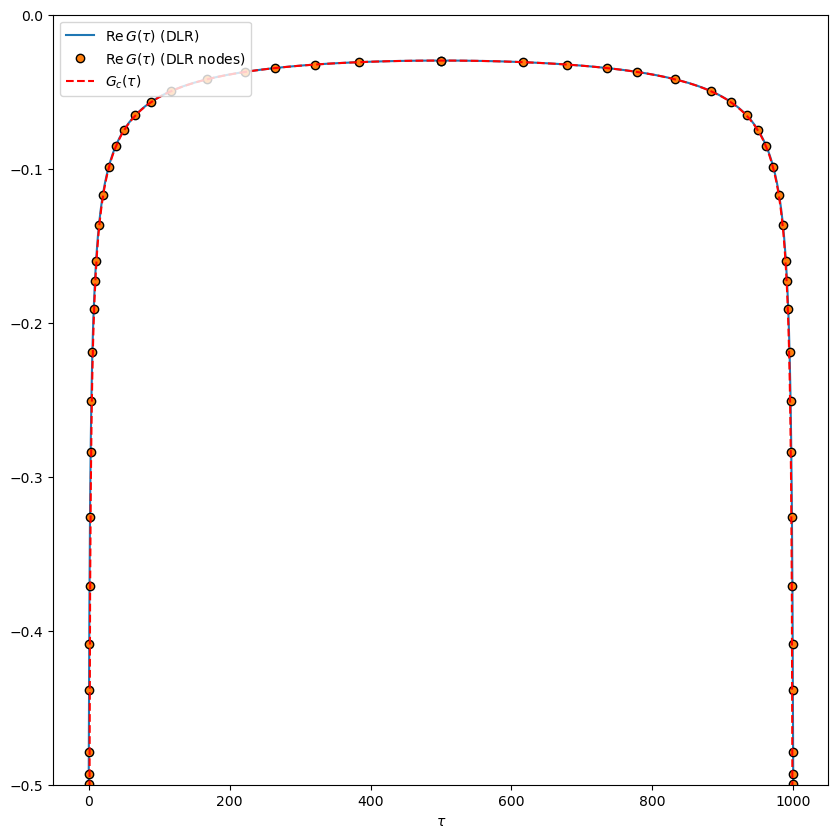

In [102]:
G_tau_dense = make_gf_imtime(G_tau["up"], n_tau=1000)                                                   # Obtain DLR expansion on dense imaginary time grid
t =  np.array([x.real for x in G_tau_dense.mesh.values()])[1:]                                          # Obtain dense grid
Gconformal = -np.pi**(1/4) / np.sqrt(2*params["beta"]) * 1/np.sqrt(np.sin(np.pi * t / params["beta"]))  # Conformal solution

plt.figure(figsize = (10,10))
oplot(G_tau_dense.real, label = r"$\mathrm{Re}\, G(\tau)$ (DLR)")
oplot(G_tau["up"].real, marker = "o", markeredgecolor = "black", label = r"$\mathrm{Re}\, G(\tau)$ (DLR nodes)")
plt.plot(t, Gconformal, label = r"$G_c(\tau)$", color = "red", linestyle = "dashed")
plt.ylim(-0.5,0)
plt.ylabel("")
plt.legend(loc="upper left")
plt.show()

Note that in this case, the Green's function is purely real. We observe a slight discrepancy with the conformal solution at the endpoints (which is expected---see the reference). You can experiment with increasing $\beta$ (it might be necessary to increase the mixing parameter $\alpha$ in order to converge), and should observe even closer agreement with the conformal solution. We can also plot the self-energy in Matsubara frequency, which is purely imaginary:

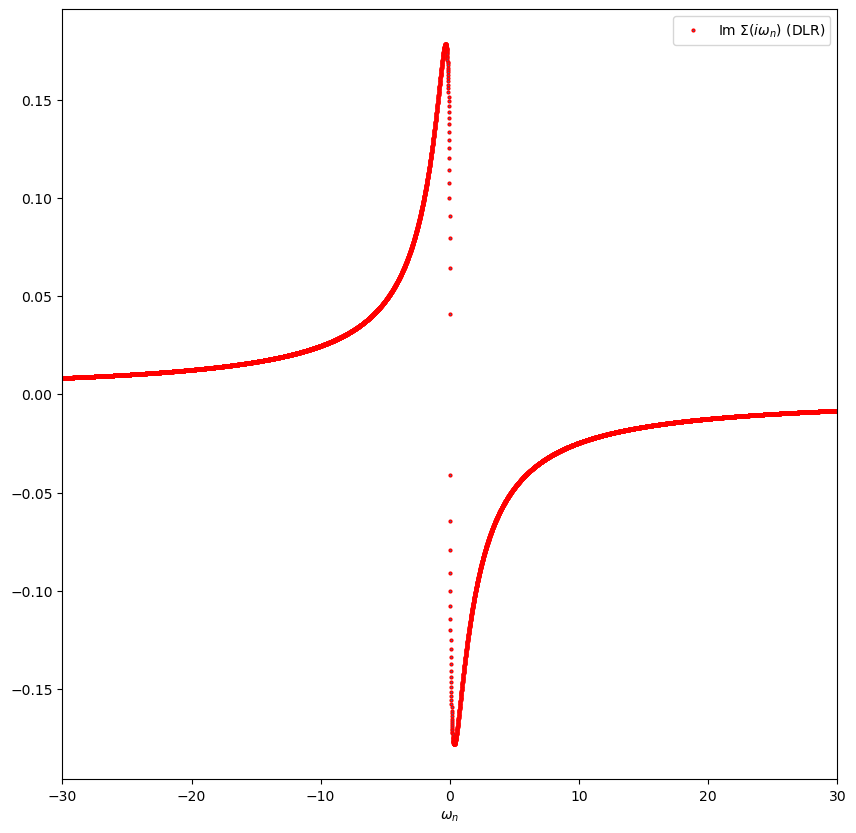

In [103]:
Sigma_iw_dense = make_gf_imfreq(Sigma_iw["up"], n_iw = 5000)    # Obtain DLR expansion on dense Matsubara frequency grid

plt.figure(figsize = (10,10))
oplot(Sigma_iw_dense.imag, marker = "o", markeredgecolor = "red", markersize=2, linestyle="none", label = r"Im $\Sigma(i \omega_n)$ (DLR)")
plt.xlim(-30,30)
plt.ylabel("")
plt.show()